In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shreevarna/winedata/wine_dataset.csv')

print('Rows, Columns:', df.shape)
df.head()

Rows, Columns: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
X = df[['proline', 'color_intensity', 'flavanoids']]
y = df['alcohol']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (178, 3)
y shape: (178,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Testing rows :', X_test.shape[0])

Training rows: 142
Testing rows : 36


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept          :', round(model.intercept_, 4))
print('Coefficient for proline         :', round(model.coef_[0], 6))
print('Coefficient for color_intensity :', round(model.coef_[1], 4))
print('Coefficient for flavanoids      :', round(model.coef_[2], 4))

Intercept          : 11.1947
Coefficient for proline         : 0.00127
Coefficient for color_intensity : 0.1422
Coefficient for flavanoids      : 0.0657


```
predicted_alcohol = intercept + (coef_proline          * proline) + (coef_color_intensity  * color_intensity) + (coef_flavanoids       * flavanoids)
```

In [6]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print('MSE :', round(mse, 4))
print('R²  :', round(r2, 4))

MSE : 0.1967
R²  : 0.6706


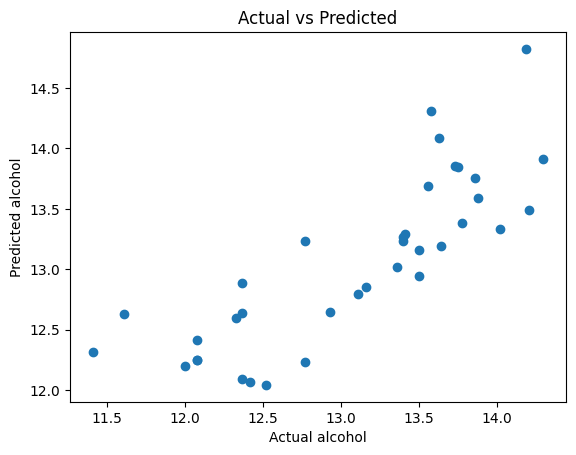

In [7]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual alcohol')
plt.ylabel('Predicted alcohol')
plt.title('Actual vs Predicted')
plt.show()

In [8]:
corr = df['total_phenols'].corr(df['flavanoids'])
print('Correlation between total_phenols and flavanoids:', round(corr, 4))

Correlation between total_phenols and flavanoids: 0.8646


In [9]:
ratio = df['flavanoids'] / df['total_phenols']

print('Min ratio :', round(ratio.min(), 4))
print('Max ratio :', round(ratio.max(), 4))
print('Mean ratio:', round(ratio.mean(), 4))
print('Std ratio :', round(ratio.std(), 4))

Min ratio : 0.2586
Max ratio : 1.5975
Mean ratio: 0.8437
Std ratio : 0.2828


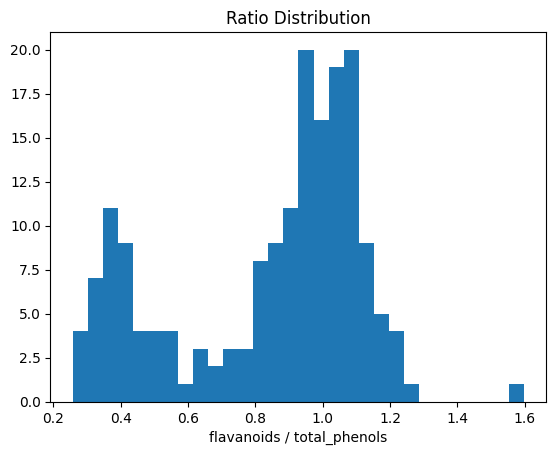

In [10]:
plt.hist(ratio, bins=30)
plt.xlabel('flavanoids / total_phenols')
plt.title('Ratio Distribution')
plt.show()

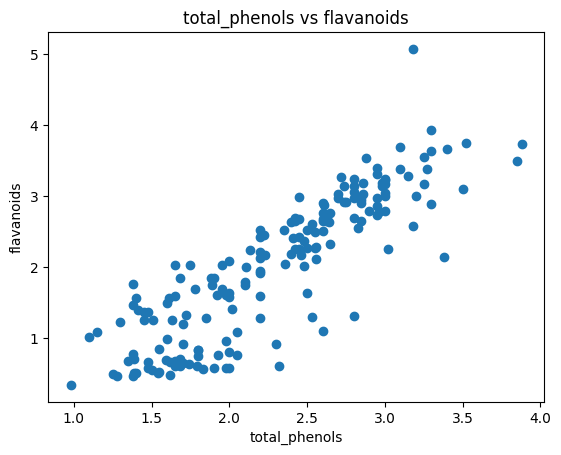

In [11]:
plt.scatter(df['total_phenols'], df['flavanoids'])
plt.xlabel('total_phenols')
plt.ylabel('flavanoids')
plt.title('total_phenols vs flavanoids')
plt.show()